### Packages

In [5]:
import numpy as np
import matplotlib as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction import text
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### Load Dataset

In [4]:
df = pd.read_csv("news_headlines_unlabeled.csv")

print(df.shape)

print(df.head(5))

(3000, 2)
   doc_id                                           headline
0       0  Carlyle Looks Toward Commercial Aerospace (Reu...
1       1  Oil and Economy Cloud Stocks' Outlook (Reuters...
2       2  Iraq Halts Oil Exports from Main Southern Pipe...
3       3  Oil prices soar to all-time record, posing new...
4       4  Stocks End Up, But Near Year Lows (Reuters) Re...


### Preprocess Text/Form term-document matrix
instead of just creating a term document matrix that looks at word frequencies per document, lets use tfidf to emphasize important words and ignore noise

In [ ]:
# Grab the text column as strings
headlines = df["headline"].astype(str).fillna("").tolist()
news_stop = {
    "says","said","new","live","update","breaking","report","reports",
    "amid","after","first","latest","day","week","year"
}
stop_words = list(text.ENGLISH_STOP_WORDS.union(news_stop))
# TF-IDF (good defaults for short texts like headlines)
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=stop_words,
    ngram_range=(1,2),
    min_df=3, # minimum number of documents that a term must appear in to be considered a term
    max_df=0.9, # if a term appears in more than that percent of documents, it will not be considered
    sublinear_tf=True, # replaces raw term frequency with 1 + log (freq)
    norm=None, # no normalization factor
    smooth_idf=True, 
    use_idf=True, 
    max_features=10000
)
tfidf_headlines = tfidf.fit_transform(headlines)

print("TF-IDF matrix shape:", tfidf_headlines.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF matrix shape: (3000, 8088)
Number of features: 8088


### Create SVD class

In [7]:

def make_svd(n_comp): 
    svd = TruncatedSVD(n_components=n_comp, n_iter=15, random_state=0)
    lsa = make_pipeline(svd, Normalizer(copy=False)) # use normalization because we want to know if documents fit categories, not how much they fit categories
    Z = lsa.fit_transform(tfidf_headlines)  
    print("Explained variance (sum):", svd.explained_variance_ratio_.sum())
    return Z

### Fit SVD

In [8]:
Z = make_svd(20)

Explained variance (sum): 0.10535089300820093


### Visualizations

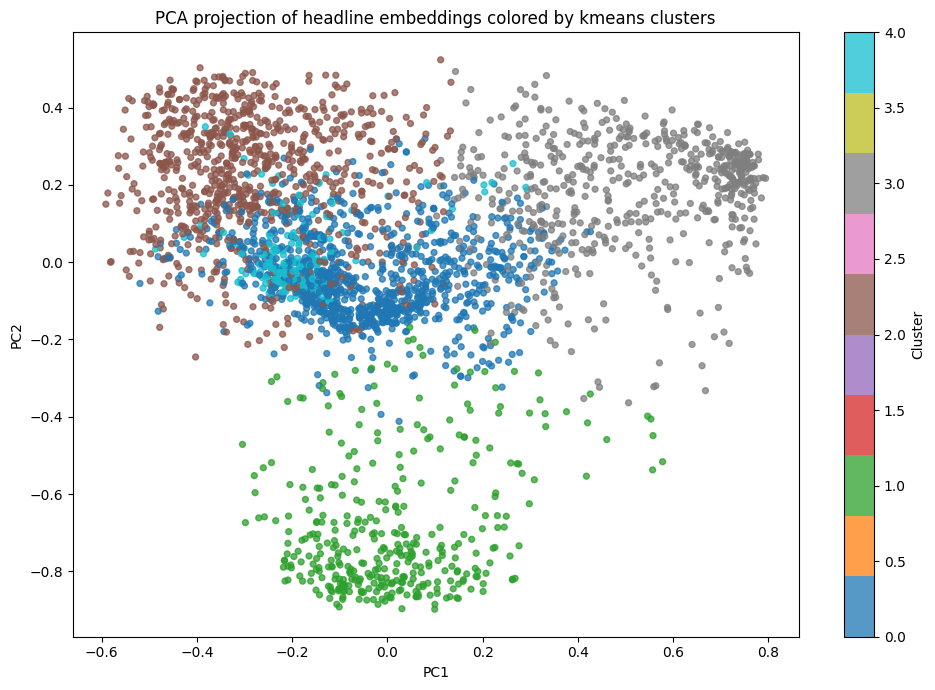

In [9]:

# Cluster the document embeddings
kmeans = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(Z)

# Project embeddings to 2D with PCA
pca = PCA(n_components=2, random_state=42)
Z_2d = pca.fit_transform(Z)

# Scatter plot colored by KMeans cluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    Z_2d[:, 0],
    Z_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=18,
    alpha=0.75,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of headline embeddings colored by kmeans clusters")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


### Create submission 

In [10]:

z_cols = [f"z{i}" for i in range(1, Z.shape[1] + 1)]
submission = pd.DataFrame(Z, columns=z_cols)
submission.insert(0, "doc_id", df["doc_id"].astype(int).to_numpy())

submission.to_csv("submission.csv", index=False)
print(submission.shape)
print(submission.head())

(3000, 21)
   doc_id        z1        z2        z3        z4        z5        z6  \
0       0  0.377496  0.497630 -0.279262  0.024814  0.067749  0.220237   
1       1  0.293083  0.359263 -0.255162  0.218906  0.045987  0.630036   
2       2  0.216746  0.426966 -0.447339  0.034719  0.334864  0.393070   
3       3  0.139516  0.362201 -0.339255  0.096874  0.022429  0.714665   
4       4  0.300786  0.334336 -0.343603  0.163998  0.101622  0.600809   

         z7        z8        z9  ...       z11       z12       z13       z14  \
0  0.074934 -0.219639 -0.026416  ...  0.033461 -0.102944  0.028537  0.238653   
1 -0.250441  0.255871 -0.230413  ...  0.003623 -0.041575  0.016073  0.086085   
2 -0.271734  0.278966  0.100452  ...  0.011739 -0.058354 -0.025017  0.024745   
3 -0.272395  0.265375 -0.074113  ... -0.039866  0.034619  0.016692 -0.036048   
4 -0.240082  0.277290 -0.148664  ...  0.007506  0.095084 -0.074933 -0.051971   

        z15       z16       z17       z18       z19       z20  
0 -0.